In [13]:
import os
import pyarrow.parquet as pq
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
BASE_DIR = r"C:\Users\Nandita\Downloads\End-to-End-Deep-Learning-for-Autonomous-Driving"
SPLIT_DIR = os.path.join(BASE_DIR, "data", "processed", "splits")

def load_split(name):
    path = os.path.join(SPLIT_DIR, f"{name}.parquet")
    table = pq.read_table(path)
    return table.to_pandas()

df_train = load_split("train")
df_val   = load_split("val")
df_test  = load_split("test")

print("Train:", len(df_train))
print("Val:  ", len(df_val))
print("Test: ", len(df_test))

Train: 9017
Val:   1932
Test:  1933


In [17]:
def split_summary(name, df):
    print(f"\n=== {name.upper()} ===")
    print("Rows:", len(df))
    print("Brake > 0.3:", (df["brake"] > 0.3).mean())
    print("Brake == 0:", (df["brake"] == 0).mean())
    print("Danger zone:", df["brake_binary"].mean())
    print("Mean speed:", df["speed_norm"].mean())
    print("Median speed:", df["speed_norm"].median())
    print("Mean nearest dist:", df["nearest_object_dist"].mean())
    print("Min nearest dist:", df["nearest_object_dist"].min())

for name, df in [("train", df_train), ("val", df_val), ("test", df_test)]:
    split_summary(name, df)



=== TRAIN ===
Rows: 9017
Brake > 0.3: 0.345791283131862
Brake == 0: 0.5579461018076965
Danger zone: 0.4613507818564933
Mean speed: 0.14903191995817983
Median speed: 0.22622944513956705
Mean nearest dist: 841.0852403077131
Min nearest dist: 43.76849698434827

=== VAL ===
Rows: 1932
Brake > 0.3: 0.34575569358178054
Brake == 0: 0.5652173913043478
Danger zone: 0.4606625258799172
Mean speed: 0.14914012601379123
Median speed: 0.22958714962005616
Mean nearest dist: 741.2507153200735
Min nearest dist: 45.28645665408554

=== TEST ===
Rows: 1933
Brake > 0.3: 0.35333678220382825
Brake == 0: 0.5416451112260735
Danger zone: 0.4619762027935851
Mean speed: 0.14719171484295604
Median speed: 0.22092890739440918
Mean nearest dist: 769.7758388220503
Min nearest dist: 43.81861882925882


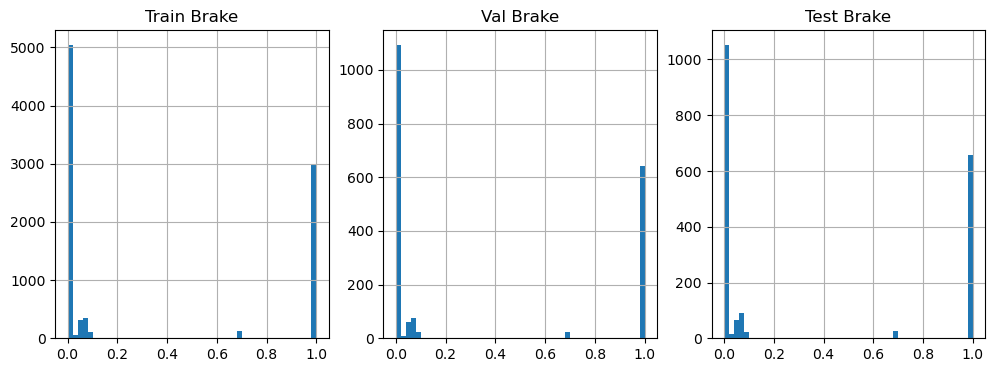

In [19]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); df_train["brake"].hist(bins=50); plt.title("Train Brake")
plt.subplot(1,3,2); df_val["brake"].hist(bins=50); plt.title("Val Brake")
plt.subplot(1,3,3); df_test["brake"].hist(bins=50); plt.title("Test Brake")
plt.show()


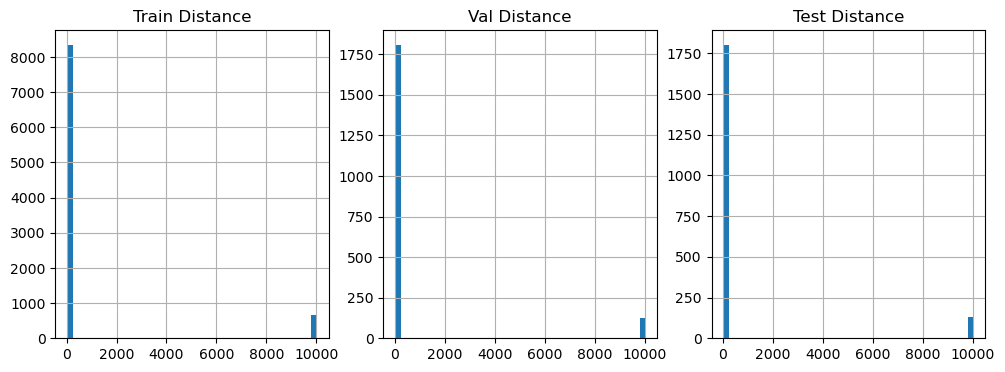

In [21]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); df_train["nearest_object_dist"].hist(bins=50); plt.title("Train Distance")
plt.subplot(1,3,2); df_val["nearest_object_dist"].hist(bins=50); plt.title("Val Distance")
plt.subplot(1,3,3); df_test["nearest_object_dist"].hist(bins=50); plt.title("Test Distance")
plt.show()

In [23]:
def compute_ttc(df):
    speed_mps = df["speed_norm"] * 120 * 0.277
    return df["nearest_object_dist"] / (speed_mps + 1e-3)

df_train["ttc"] = compute_ttc(df_train)
df_val["ttc"]   = compute_ttc(df_val)
df_test["ttc"]  = compute_ttc(df_test)

for name, df in [("train", df_train), ("val", df_val), ("test", df_test)]:
    print(name, "TTC < 2s:", (df["ttc"] < 2).mean())

train TTC < 2s: 0.0
val TTC < 2s: 0.0
test TTC < 2s: 0.0


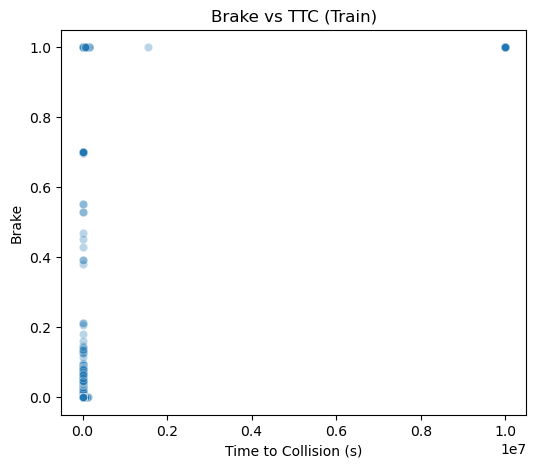

In [25]:
plt.figure(figsize=(6,5))
sns.scatterplot(x=df_train["ttc"], y=df_train["brake"], alpha=0.3)
plt.xlabel("Time to Collision (s)")
plt.ylabel("Brake")
plt.title("Brake vs TTC (Train)")
plt.show()


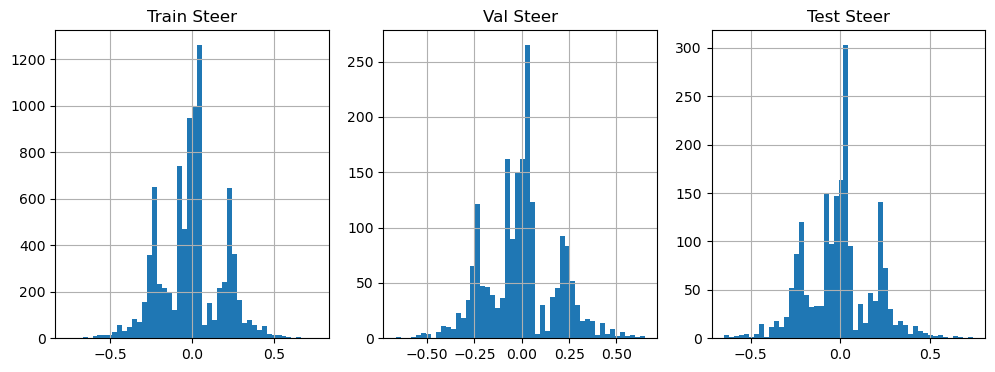

In [27]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); df_train["steer"].hist(bins=50); plt.title("Train Steer")
plt.subplot(1,3,2); df_val["steer"].hist(bins=50); plt.title("Val Steer")
plt.subplot(1,3,3); df_test["steer"].hist(bins=50); plt.title("Test Steer")
plt.show()

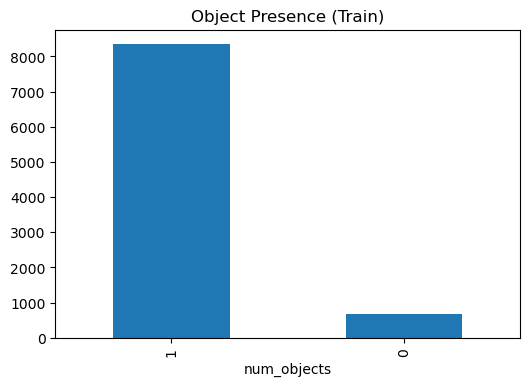

In [29]:
df_train["num_objects"] = df_train["nearest_object_dist"].apply(lambda x: 0 if x > 5000 else 1)

plt.figure(figsize=(6,4))
df_train["num_objects"].value_counts().plot(kind="bar")
plt.title("Object Presence (Train)")
plt.show()

In [33]:
def safety_report(name, df):
    return {
        "split": name,
        "rows": len(df),
        "brake>0.3": float((df["brake"] > 0.3).mean()),
        "danger_zone": float(df["brake_binary"].mean()),
        "ttc<2s": float((df["ttc"] < 2).mean()),
        "mean_speed": float(df["speed_norm"].mean()),
        "mean_dist": float(df["nearest_object_dist"].mean()),
    }

report = [
    safety_report("train", df_train),
    safety_report("val", df_val),
    safety_report("test", df_test),
]

pd.DataFrame(report)


,split,rows,brake>0.3,danger_zone,ttc<2s,mean_speed,mean_dist
0,train,9017,0.345791,0.461351,0.0,0.149032,841.085240
1,val,1932,0.345756,0.460663,0.0,0.149140,741.250715
2,test,1933,0.353337,0.461976,0.0,0.147192,769.775839
